Upload Titanic-Dataset.csv


Saving Titanic-Dataset.csv to Titanic-Dataset.csv
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4    

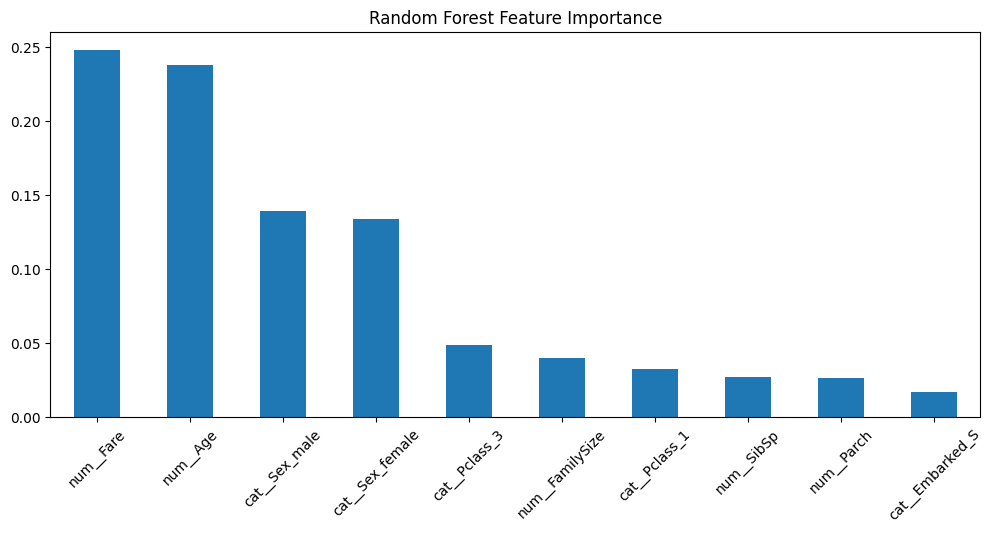

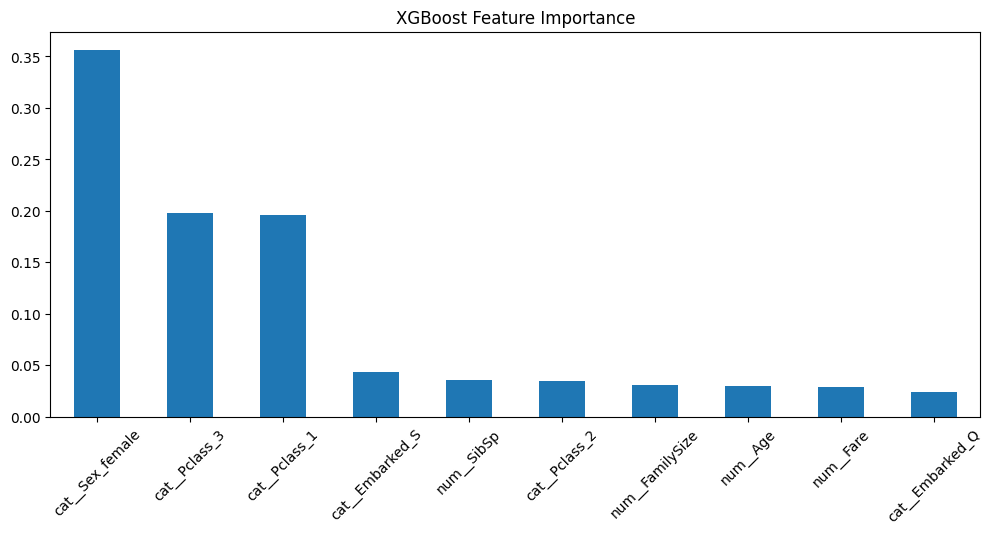


Random Forest Report

              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.79      0.70      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179


XGBoost Report

              precision    recall  f1-score   support

           0       0.80      0.88      0.84       110
           1       0.78      0.65      0.71        69

    accuracy                           0.79       179
   macro avg       0.79      0.77      0.77       179
weighted avg       0.79      0.79      0.79       179


Task Completed Successfully!


In [1]:
# ===============================================================
# Neurofive ML Track - Week 4
# Ensemble Learning: Random Forest vs XGBoost
# Author: Faizan Khan
# ===============================================================

# ==========================
# Install XGBoost
# ==========================
!pip -q install xgboost

# ==========================
# Upload Dataset
# ==========================
from google.colab import files

print("Upload Titanic-Dataset.csv")
uploaded = files.upload()

# ==========================
# Import Libraries
# ==========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# ==========================
# Load Dataset
# ==========================
df = pd.read_csv("Titanic-Dataset.csv")

print(df.head())

# ==========================
# Feature Engineering
# ==========================

df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

# ==========================
# Drop Unnecessary Columns
# ==========================
drop_columns = ["PassengerId","Name","Ticket","Cabin"]

for col in drop_columns:
    if col in df.columns:
        df.drop(col,axis=1,inplace=True)

# ==========================
# Features & Target
# ==========================
X = df.drop("Survived",axis=1)

y = df["Survived"]

# ==========================
# Numerical Columns
# ==========================
numeric_features = [
    "Age",
    "Fare",
    "SibSp",
    "Parch",
    "FamilySize"
]

numeric_features = [c for c in numeric_features if c in X.columns]

# ==========================
# Categorical Columns
# ==========================
categorical_features = [
    "Sex",
    "Embarked",
    "Pclass",
    "IsAlone"
]

categorical_features = [c for c in categorical_features if c in X.columns]

# ==========================
# Pipelines
# ==========================
numeric_pipeline = Pipeline(
    steps=[
        ("imputer",SimpleImputer(strategy="median")),
        ("scaler",StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer",SimpleImputer(strategy="most_frequent")),
        ("encoder",OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num",numeric_pipeline,numeric_features),
        ("cat",categorical_pipeline,categorical_features)
    ]
)

# ==========================
# Train Test Split
# ==========================
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =====================================================
# Logistic Regression
# =====================================================
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        ("model",LogisticRegression(max_iter=1000))
    ]
)

logistic_pipeline.fit(X_train,y_train)

lr_pred = logistic_pipeline.predict(X_test)

lr_accuracy = accuracy_score(y_test,lr_pred)

# =====================================================
# Random Forest
# =====================================================
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        ("model",RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]
)

rf_pipeline.fit(X_train,y_train)

rf_pred = rf_pipeline.predict(X_test)

rf_accuracy = accuracy_score(y_test,rf_pred)

# =====================================================
# XGBoost
# =====================================================
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        ("model",XGBClassifier(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=4,
            random_state=42,
            eval_metric="logloss"
        ))
    ]
)

xgb_pipeline.fit(X_train,y_train)

xgb_pred = xgb_pipeline.predict(X_test)

xgb_accuracy = accuracy_score(y_test,xgb_pred)

# =====================================================
# Results
# =====================================================

print("\n===============================")
print("MODEL COMPARISON")
print("===============================")

print(f"Logistic Regression Accuracy : {lr_accuracy:.4f}")
print(f"Random Forest Accuracy       : {rf_accuracy:.4f}")
print(f"XGBoost Accuracy             : {xgb_accuracy:.4f}")

# =====================================================
# Comparison Table
# =====================================================

comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy":[
        lr_accuracy,
        rf_accuracy,
        xgb_accuracy
    ]
})

print("\n")
print(comparison)

# =====================================================
# Feature Importance
# =====================================================

feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

rf_importance = rf_pipeline.named_steps["model"].feature_importances_

xgb_importance = xgb_pipeline.named_steps["model"].feature_importances_

# ---------------- RF ----------------
plt.figure(figsize=(12,5))

rf_series = pd.Series(
    rf_importance,
    index=feature_names
)

rf_series.sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Random Forest Feature Importance")

plt.xticks(rotation=45)

plt.show()

# ---------------- XGB ----------------
plt.figure(figsize=(12,5))

xgb_series = pd.Series(
    xgb_importance,
    index=feature_names
)

xgb_series.sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("XGBoost Feature Importance")

plt.xticks(rotation=45)

plt.show()

# =====================================================
# Classification Reports
# =====================================================

print("\nRandom Forest Report\n")

print(classification_report(y_test,rf_pred))

print("\nXGBoost Report\n")

print(classification_report(y_test,xgb_pred))

print("\nTask Completed Successfully!")